# Lab 2.8: Tree Based Methods

In this case, we will be conduct a simpler exercise with decision trees using previous implementations. In particular, we will make use of several implemented methods in ML libraries s.a. `sklearn` (_that should be good news for you, doesn't it?_). With this, we will try to explore the main characteristics of decision trees, that you will also have to explore in the more theoretical part of the lab (the other exercise, the one on the pdf).

We will begin, as usual, importing the relevant libraries:

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mode


# ML libraries to construct, use and analyse the trees
from sklearn.tree import DecisionTreeRegressor, export_graphviz, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from io import StringIO
from IPython.display import Image
from sklearn.metrics import mean_squared_error, confusion_matrix, plot_confusion_matrix
import pydotplus

from sklearn.metrics import mean_squared_error

ImportError: cannot import name 'plot_confusion_matrix' from 'sklearn.metrics' (/usr/local/lib/python3.10/dist-packages/sklearn/metrics/__init__.py)

We will first apply this to a regression dataset so that you see the way the model is constructed for this case

## Regression Tree

For starters, let us try out a regression tree. To that end, first load the `Hitters.csv` dataset from the `Data`
folder.

In [3]:
hitters = pd.read_csv("/content/drive/My Drive/Hitters.csv", sep = ",")

hitters_clean = hitters.dropna()
# Print the columns here to check their names
print(hitters.columns)

Index(['Player', 'AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years',
       'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League',
       'Division', 'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object')


For this first case, we will only use the variables `Years` and `Hits` for the tree. Our target variable will be `Salary`. Separate them into `X` and `y`

In [4]:
# Separate the independent variables (X) from the dependent one (y - salary)

# Variables independientes (X)
X = hitters_clean[['Years', 'Hits']].copy()

# Variable dependiente (y - salario)
y = hitters_clean['Salary'].copy()

Construct a _decision tree regressor_ using the `sklearn` function and fit it. To do that, check out the `DecisionTreeRegressor` in sklearn and implement it here.

For reproducibility, fix the `random_state` to `0` and the `max_leaf_nodes` to `3` (make sure you know what this last thing does!)

In [5]:
# Construct the regressor
regressor = DecisionTreeRegressor(random_state=0, max_leaf_nodes=3)

# Ajustar el regresor a los datos
regressor.fit(X, y)

DecisionTreeRegressor(max_leaf_nodes=3, random_state=0)

Now we will employ some functions engrained in `StringIO` alongside the method `export_graphviz` from the `tree` object in sklearn. This will enable us to visualize the constructed tree.

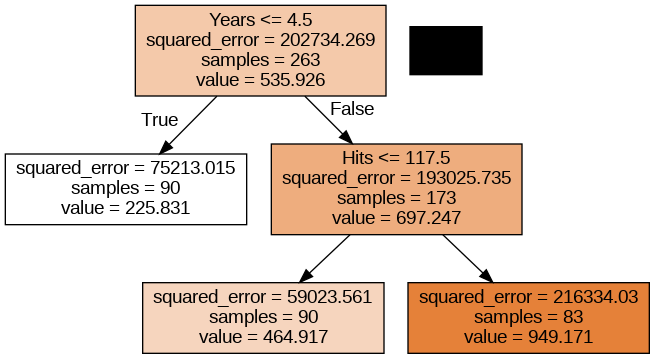

In [6]:
dot_data = StringIO()
export_graphviz(regressor,
                out_file=dot_data,
                feature_names=['Years', 'Hits'],
                filled=True,
                class_names=None)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

Now we will plot the decision regions using the information on the cuts. Add lines wherever needed so that you can see the decision boundaries for the regression tree above

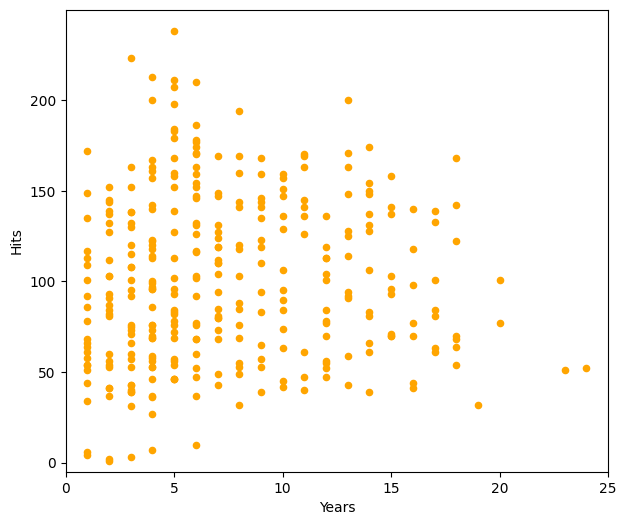

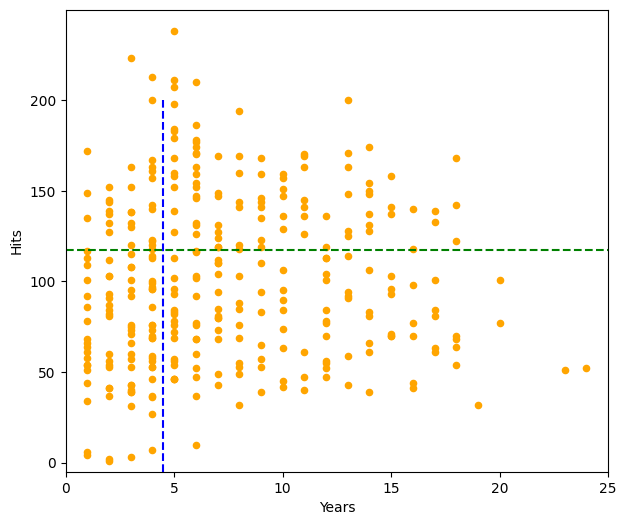

In [7]:
hitters.plot('Years', 'Hits', kind='scatter', color='orange', figsize=(7,6))
plt.xlim(0,25)
plt.ylim(ymin=-5)

# Add whatever you may need here to clearly plot the decision boundaries
# TODO

# Crear un objeto StringIO
dot_data = StringIO()

# Exportar el árbol de regresión a formato DOT
export_graphviz(regressor,
                out_file=dot_data,
                feature_names=['Years', 'Hits'],
                filled=True,
                class_names=None)

# Crear el gráfico del árbol
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

# Mostrar el gráfico del árbol
Image(graph.create_png())

# Datos de dispersión de Years y Hits
hitters.plot('Years', 'Hits', kind='scatter', color='orange', figsize=(7,6))
plt.xlim(0,25)
plt.ylim(ymin=-5)

# Agregar líneas para mostrar las fronteras de decisión
# Frontera de decisión para Years <= 4.5
plt.plot([4.5, 4.5], [-5, 200], color='blue', linestyle='--')
# Frontera de decisión para Hits <= 117.5
plt.plot([0, 25], [117.5, 117.5], color='green', linestyle='--')

plt.show()


## Tree Size

Now, for the previous part we limited the growth of the tree so that we recovered a simple (but easily interpretable) tree. Now we will go all-out: we will construct a more exhaustive tree using different variables. For this particular case, let us use **all variables except** `League`, `Division`, `NewLeague` and `Salary` as independent variables to predict, precisely, the `Salary` value.

In [8]:
# Construct the input variable dataset
X = hitters_clean.copy()
# Print the column names to check
X = X.drop(['Player','League', 'Division', 'NewLeague', 'Salary'], axis=1)

print(X.columns)

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
       'Errors'],
      dtype='object')


We will now perform the train/test split, but we will do it so that the proportion of train and test examples is $50\%$ (that is, train and test consist on $50\%$ of the datapoints).

In [9]:
# Perform the train-test split here. Do it so that the
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)


Now, train the tree to its fullest extent: put no limits on the growth and see what happens. You can re-use some of the previous `graphviz` code to visualize the tree here. Plot the complete tree.

In [10]:
# Train the tree without limits to its growth (random_state = 0)
unlimited_tree_regressor = DecisionTreeRegressor(random_state=0)
unlimited_tree_regressor.fit(x_train, y_train) # TODO

DecisionTreeRegressor(random_state=0)

Reuse the code you need to plot the tree here

[Text(0.5662377450980393, 0.9615384615384616, 'x[11] <= 278.0\nsquared_error = 173437.71\nsamples = 131\nvalue = 531.198'),
 Text(0.3386029411764706, 0.8846153846153846, 'x[5] <= 2.5\nsquared_error = 78765.079\nsamples = 69\nvalue = 282.208'),
 Text(0.3307598039215686, 0.8076923076923077, 'squared_error = 0.0\nsamples = 1\nvalue = 2127.333'),
 Text(0.34644607843137254, 0.8076923076923077, 'x[7] <= 1407.5\nsquared_error = 29121.136\nsamples = 68\nvalue = 255.074'),
 Text(0.18872549019607843, 0.7307692307692307, 'x[7] <= 720.5\nsquared_error = 6194.029\nsamples = 48\nvalue = 177.608'),
 Text(0.10098039215686275, 0.6538461538461539, 'x[8] <= 132.0\nsquared_error = 1293.389\nsamples = 24\nvalue = 115.417'),
 Text(0.045098039215686274, 0.5769230769230769, 'x[1] <= 34.0\nsquared_error = 901.621\nsamples = 16\nvalue = 100.812'),
 Text(0.03725490196078431, 0.5, 'squared_error = 0.0\nsamples = 1\nvalue = 190.0'),
 Text(0.052941176470588235, 0.5, 'x[11] <= 36.0\nsquared_error = 396.082\nsamples 

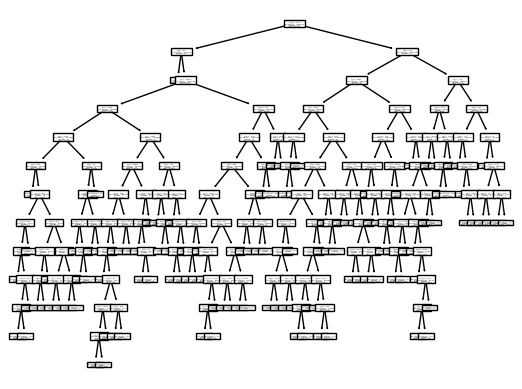

In [11]:
# TODO: Your code here! #El código reutilizado no me funcionaba
plot_tree(unlimited_tree_regressor)

Maybe we went _a bit too far_ with the tree... Let's set up some limitations to see everything better. Try setting the `max_features` to 9, and the `max_depth` to 4. (_It is important you understand what these parameters do! Check out the documentation in the [library](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)_)

In [12]:
regressor_2 = DecisionTreeRegressor(random_state=0, max_features=9, max_depth=4)
regressor_2.fit(x_train, y_train)


DecisionTreeRegressor(max_depth=4, max_features=9, random_state=0)

Reuse the code you may need to plot the tree here

[Text(0.3958333333333333, 0.9, 'x[7] <= 1779.5\nsquared_error = 173437.71\nsamples = 131\nvalue = 531.198'),
 Text(0.125, 0.7, 'x[3] <= 4.0\nsquared_error = 77680.147\nsamples = 62\nvalue = 265.871'),
 Text(0.08333333333333333, 0.5, 'squared_error = 0.0\nsamples = 1\nvalue = 2127.333'),
 Text(0.16666666666666666, 0.5, 'x[8] <= 358.0\nsquared_error = 21218.431\nsamples = 61\nvalue = 235.355'),
 Text(0.08333333333333333, 0.3, 'x[8] <= 177.5\nsquared_error = 6927.493\nsamples = 49\nvalue = 181.84'),
 Text(0.041666666666666664, 0.1, 'squared_error = 1293.389\nsamples = 24\nvalue = 115.417'),
 Text(0.125, 0.1, 'squared_error = 4034.467\nsamples = 25\nvalue = 245.607'),
 Text(0.25, 0.3, 'x[13] <= 1058.0\nsquared_error = 20128.089\nsamples = 12\nvalue = 453.875'),
 Text(0.20833333333333334, 0.1, 'squared_error = 9538.657\nsamples = 11\nvalue = 486.045'),
 Text(0.2916666666666667, 0.1, 'squared_error = 0.0\nsamples = 1\nvalue = 100.0'),
 Text(0.6666666666666666, 0.7, 'x[0] <= 418.5\nsquared_er

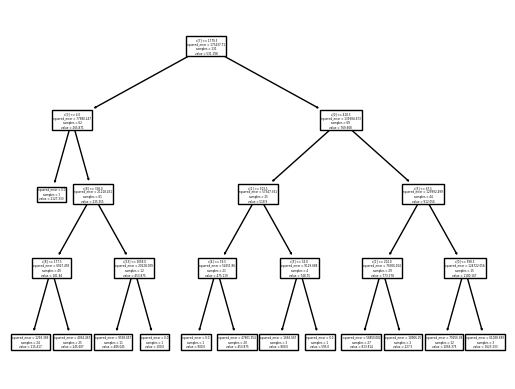

In [13]:
# TODO: Your code here!
plot_tree(regressor_2)

Let us see if this tree works well at all... Since we are performing regression, we can obtain the RMSE (we use the Root MSE since it shares the same dimensions of the outputs):

In [14]:
# TODO: Obtain the predictions for x_test

# Obtain predictions for x_test
predictions = regressor_2.predict(x_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, predictions))

# Print the RMSE
print("Root Mean Squared Error (RMSE):", rmse)

# TODO: Print the RMSE for the predictions

Root Mean Squared Error (RMSE): 369.8405919459622


Now, the question is: how do we know which tree depth to select here? As you may expect, the answer is, as almost always here, performing _cross validation_. In this particular instance we will not conduct exhaustive cross validation. Instead, we will do it in a very simple manner, obtaining *a single tree* for each depth value we want, fitting it to the data and seeing how well does it perform both in train and test  fitted to the data. To do this, do the following:
* Fit a **fixed max depth** (`i`) decision tree regressor using *all `x_train` variables*. Also, *fix the `random state` to 1* for reproducibility.
* Register its train and test RMSEs
* Plot the train and test RMSE curves for each `i` depth  

Make sure that you explore _enough_ depth values.

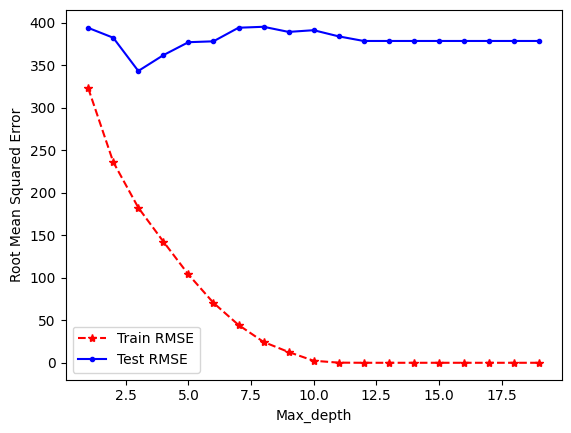

In [15]:
# Lists to store the results
train_rmse = []
test_rmse = []

# Range of depths to be explored
tree_size = np.arange(1, 20)

for i in tree_size:
    # Train the decision tree regressor with the set depth
    regressor = DecisionTreeRegressor(random_state=1, max_depth=i)
    regressor.fit(x_train, y_train)

    # Obtain predictions for train and test sets
    train_predictions = regressor.predict(x_train)
    test_predictions = regressor.predict(x_test)

    # Calculate RMSE for train and test sets
    train_rmse.append(np.sqrt(mean_squared_error(y_train, train_predictions)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, test_predictions)))

# Plot the results
plt.plot(tree_size, train_rmse, 'r*--', label='Train RMSE')
plt.plot(tree_size, test_rmse, 'b.-', label='Test RMSE')
plt.xlabel('Max_depth')
plt.ylabel('Root Mean Squared Error')
plt.legend()
plt.show()



Since we are not really making CV, we do not have multiple values for the train and test RMSE for each tree. Therefore, we *do not* have errorbars in the previous plot. That should raise some suspicions from your part.

> Question: What happens if we change the `random_state` value? Are the previous results robust?

To answer the previous question you can try out code in the next cell. Feel free to try whatever you think is needed here.

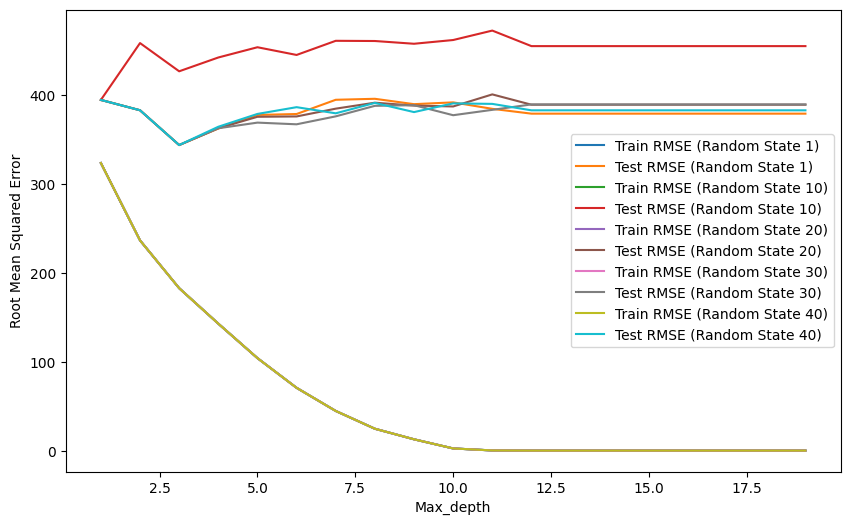

In [16]:
# TODO: Your code here!
# Lists to store the results
train_rmse_dict = {}
test_rmse_dict = {}

# Range of depths to be explored
tree_size = np.arange(1, 20)

# Range of random_state values to be explored
random_states = [1, 10, 20, 30, 40]

for rs in random_states:
    train_rmse = []
    test_rmse = []
    for i in tree_size:
        # Train the decision tree regressor with the set depth and random_state
        regressor = DecisionTreeRegressor(random_state=rs, max_depth=i)
        regressor.fit(x_train, y_train)

        # Obtain predictions for train and test sets
        train_predictions = regressor.predict(x_train)
        test_predictions = regressor.predict(x_test)

        # Calculate RMSE for train and test sets
        train_rmse.append(np.sqrt(mean_squared_error(y_train, train_predictions)))
        test_rmse.append(np.sqrt(mean_squared_error(y_test, test_predictions)))

    # Store the results for the current random_state
    train_rmse_dict[rs] = train_rmse
    test_rmse_dict[rs] = test_rmse

# Plot the results for each random_state
plt.figure(figsize=(10, 6))
for rs in random_states:
    plt.plot(tree_size, train_rmse_dict[rs], label=f'Train RMSE (Random State {rs})')
    plt.plot(tree_size, test_rmse_dict[rs], label=f'Test RMSE (Random State {rs})')

plt.xlabel('Max_depth')
plt.ylabel('Root Mean Squared Error')
plt.legend()
plt.show()


In order to get more acquainted with the results, check out what happens if you include less  `x_train` features. To do so, change what you need from the previous block of code and put it in the next block here.
> Question: Do you see any important changes? How do you explain this?  

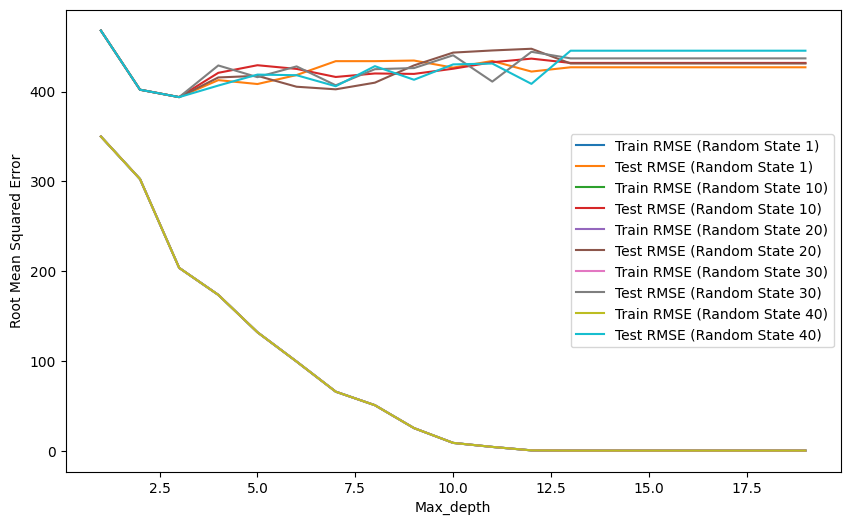

In [17]:
# TODO: Your code here!
# Lists to store the results
train_rmse_dict = {}
test_rmse_dict = {}

# Range of depths to be explored
tree_size = np.arange(1, 20)

# Range of random_state values to be explored
random_states = [1, 10, 20, 30, 40]

# Select a subset of features from x_train
selected_features = x_train[['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years']]  # Selecting the first 5 features

for rs in random_states:
    train_rmse = []
    test_rmse = []
    for i in tree_size:
        # Train the decision tree regressor with the set depth and random_state
        regressor = DecisionTreeRegressor(random_state=rs, max_depth=i)
        regressor.fit(selected_features, y_train)  # Fit with the selected features

        # Obtain predictions for train and test sets
        train_predictions = regressor.predict(selected_features)
        test_predictions = regressor.predict(x_test[['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years']])  # Use the same subset of features for x_test

        # Calculate RMSE for train and test sets
        train_rmse.append(np.sqrt(mean_squared_error(y_train, train_predictions)))
        test_rmse.append(np.sqrt(mean_squared_error(y_test, test_predictions)))

    # Store the results for the current random_state
    train_rmse_dict[rs] = train_rmse
    test_rmse_dict[rs] = test_rmse

# Plot the results for each random_state
plt.figure(figsize=(10, 6))
for rs in random_states:
    plt.plot(tree_size, train_rmse_dict[rs], label=f'Train RMSE (Random State {rs})')
    plt.plot(tree_size, test_rmse_dict[rs], label=f'Test RMSE (Random State {rs})')

plt.xlabel('Max_depth')
plt.ylabel('Root Mean Squared Error')
plt.legend()
plt.show()


## Classification Tree

In order to complete this practical exercises with trees, we will also try out some classification trees to later do ensembles. Let us see how this works.

First, load the `Carseat.csv` dataset from `Data` (make sure to remove the NAs, as before)

In [32]:
# Load the dataset (remove the NAs)
carseats = pd.read_csv("/content/drive/My Drive/Carseat.csv", sep = ",")

carseats_clean = carseats.dropna()
# Print the columns here to check their names
print(carseats_clean.columns)

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')


Convert the remaining variables to make them usable here

In [33]:
# Assuming 'sales' is the column name for sales data in the 'carseats' DataFrame
carseats_clean['high'] = (carseats_clean['Sales'] > 8).astype(int)
print(carseats_clean.columns)

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US', 'high'],
      dtype='object')


Make it so that we have a new binary variable called `high`. This variable should be `1` when `sales` are over 8, and `0` otherwise.

The variables `ShelveLoc`, `Urban` and `US` need to be converted to categorical variables to be correctly used. To that end, I suggest you use `pd.factorize` (although feel free to do as you will here...)

In [34]:
# TODO: Your code here!
carseats_clean['ShelveLoc'] = pd.factorize(carseats_clean['ShelveLoc'])[0]
carseats_clean['Urban'] = pd.factorize(carseats_clean['Urban'])[0]
carseats_clean['US'] = pd.factorize(carseats_clean['US'])[0]
print(carseats_clean.columns)

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US', 'high'],
      dtype='object')


Now, we will employ all variables to predict the `high` value (except `Sales` and `high`, for obvious reasons). Note that we have essentially converted a _regression_ problem into a _binary classification_ one.

In [38]:
X = carseats_clean.drop(columns = ['Sales', 'high'])
y = carseats_clean['high']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)


Construct a decision tree classifier. To control for the depth, we will fix it to a *maximum depth of 6*. Use as impurity criteria the **Gini index**.

In [39]:
carseats_classifier = DecisionTreeClassifier(max_depth=6, criterion='gini', random_state=0)

carseats_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=0)

Plot the tree (again, reuse whatever you may need here)

[Text(0.41847826086956524, 0.9285714285714286, 'Price <= 94.5\ngini = 0.484\nsamples = 200\nvalue = [118, 82]\nclass = 0'),
 Text(0.13043478260869565, 0.7857142857142857, 'Age <= 55.5\ngini = 0.349\nsamples = 40\nvalue = [9, 31]\nclass = 1'),
 Text(0.08695652173913043, 0.6428571428571429, 'ShelveLoc <= 0.5\ngini = 0.159\nsamples = 23\nvalue = [2, 21]\nclass = 1'),
 Text(0.06521739130434782, 0.5, 'Income <= 79.5\ngini = 0.444\nsamples = 6\nvalue = [2, 4]\nclass = 1'),
 Text(0.043478260869565216, 0.35714285714285715, 'Price <= 89.5\ngini = 0.444\nsamples = 3\nvalue = [2, 1]\nclass = 0'),
 Text(0.021739130434782608, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = 0'),
 Text(0.06521739130434782, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = 1'),
 Text(0.08695652173913043, 0.35714285714285715, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]\nclass = 1'),
 Text(0.10869565217391304, 0.5, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]\nclass = 1'),
 Text(0.

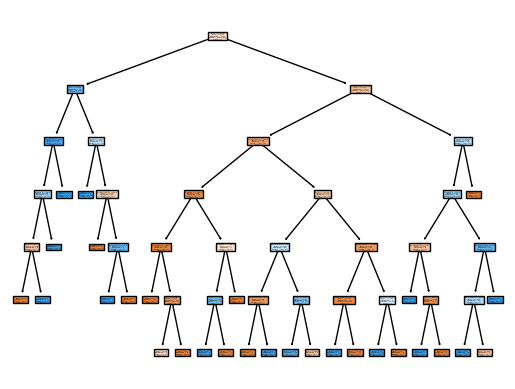

In [40]:
# TODO: Your code here!
plot_tree(carseats_classifier, feature_names=X.columns, class_names=['0', '1'], filled=True)

Let us now assess the quality of the tree. To that end, **represent the confusion matrix** for the test data

In [41]:
# TODO: Your code here!
plt.figure(figsize=(8, 6))
plot_confusion_matrix(carseats_classifier, X_test, y_test) #no se me importa la funcion plot_confusion_matrix
plt.show()

NameError: name 'plot_confusion_matrix' is not defined

<Figure size 800x600 with 0 Axes>

> Questions:
> * What is the **precision** of this tree?
> * Do you consider the dataset balanced?

# Ensembles

Now we will try out some of the ensemble methods from class. Remember there is an stochastic component embedded in these for the most part, so we may not recover exactly the same results twice depending on how you implement things.

## Bagging

The decision tree models mentioned above usually suffers from high variance. **B**ootstrap **agg**regation, or **bagging** usually helps with this issue. To do bagging here, we will do it both by hand and by employing the sklearn function.

First, let's go with the *by-hand* implementation

In [42]:
# Set the bagging parameters
n_estimators = 10  # Number of decision trees in the ensemble
max_samples = 0.8  # Proportion of samples to be used for each bootstrap sample
# Store the predictions
predictions = []

for _ in range(n_estimators):
    # Create a bootstrap sample
    sample_indices = np.random.choice(range(len(X_train)), size=int(max_samples * len(X_train)), replace=True)
    X_bootstrap = X_train.iloc[sample_indices]
    y_bootstrap = y_train.iloc[sample_indices]

    # Train a decision tree classifier on the bootstrap sample
    decision_tree = DecisionTreeClassifier(random_state=0, max_depth=None)
    decision_tree.fit(X_bootstrap, y_bootstrap)

    # Make predictions on the test set using the trained decision tree
    y_pred = decision_tree.predict(X_test)
    predictions.append(y_pred)

# Combine predictions
# For classification, use majority voting
majority_vote = np.mean(predictions, axis=0)



Print the confusion matrix

In [43]:
# TODO: Your code here! Use majority_vote and y_test
binary_predictions = np.where(majority_vote > 0.5, 1, 0)

# Compute the confusion matrix
cm = confusion_matrix(y_test, binary_predictions)


Let's see how this is done in `sklearn`... Fit it and show the confusion matrix

In [46]:
bagging = BaggingClassifier(random_state=0) #: Create a BaggingClassifier (fix random_state to 0)

# TODO: Train it with the training data
bagging.fit(X_train, y_train)

# TODO: Obtain the predictions
bagging_pred = bagging.predict(X_test)

# TODO: Print the confusion matrix (use the confusion_matrix function)

cm = confusion_matrix(y_test, bagging_pred)
print(cm)

[[97 21]
 [28 54]]


We will use the `sklearn` implementation to study the variable importance. *Make sure you understand how this is done!*

## Random Forest

We will also do this in the RF case. First, we will implement it by hand. Feel free to use the previous code and modify it as you may see fit to do RF here!

In [47]:

# RF parameters
n_estimators = 10  # Number of decision trees in the forest
max_features = 0.8  # Proportion of features to consider for each split

# Train decision trees with random feature selection and make predictions
predictions = []
for _ in range(n_estimators):
    # Create a bootstrap sample
    sample_indices = np.random.choice(len(X_train), len(X_train), replace=True)
    X_bootstrap = X_train.iloc[sample_indices]
    y_bootstrap = y_train.iloc[sample_indices]

    # Train a decision tree classifier on the bootstrap sample with random feature selection
    decision_tree = RandomForestClassifier(n_estimators=1, max_features=max_features, random_state=0)
    decision_tree.fit(X_bootstrap, y_bootstrap)

    # Make predictions on the test set using the trained decision tree
    y_pred = decision_tree.predict(X_test)
    predictions.append(y_pred)

# Combine predictions using majority voting
majority_vote = np.mean(predictions, axis=0)

Print the confusion matrix

In [48]:
# TODO: Your code here!
binary_predictions = (majority_vote > 0.5).astype(int)

cm = confusion_matrix(y_test, binary_predictions)
print(cm)

[[100  18]
 [ 39  43]]


Let us do it again with `sklearn` so you see the differences... Show the confusion matrix. In this last part there may be some differences with your run, which are due to the randomness of the classifiers constructed. Do not worry too much about it here.

In [49]:
# TODO: Construct the RF classifier with RandomForestClassifier. Fix the random_state to 0, n_estimators to 10 and max_features to 0.8
rf = RandomForestClassifier(n_estimators=10, max_features=0.8, random_state=0)

# Train the classifier
rf.fit(X_train, y_train)

# Predict the test values
rf_pred = rf.predict(X_test)

# Obtain the confusion matrix
cm = confusion_matrix(y_test, rf_pred)
print(cm)


[[103  15]
 [ 34  48]]


Using again the `sklearn` implementation, we will study the feature importance

<Axes: >

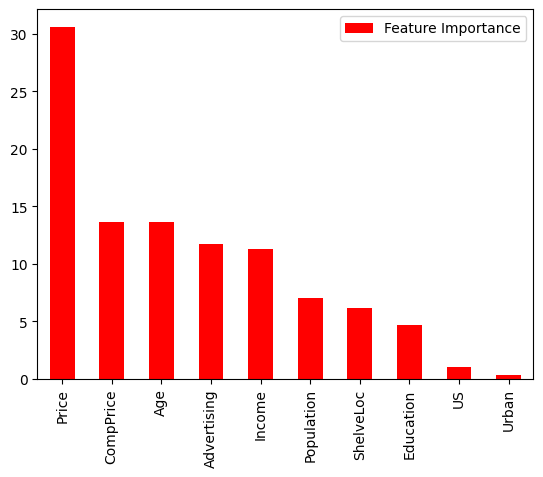

In [50]:
rf_featureImportance= pd.DataFrame({'Feature Importance':rf.feature_importances_*100}, index= X.columns)
rf_featureImportance.sort_values('Feature Importance', ascending=False).plot(kind='bar', color='red')

> Question: Given the models thus far (simple tree, bagging and RF), which one would you choose and why?